# LLM Pretrainning

In [2]:
import torch
from src.Architecture.GPTModel import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,  # we shorten the length from 1,024 to 256
    "embedding_dim": 768,
    "num_layers": 12,
    "num_heads": 12,
    "dropout": 0.1,         # It is possible and common to set dropout to 0.0
    "attention_dropout": 0.1,
    "ffn_dropout": 0.1,
    "qkv_bias": False,
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query)

In [3]:
import tiktoken
from src.Utilities.GenerationUtilities import generate_text_simple, text_to_token_ids, token_ids_to_text

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text: \n", token_ids_to_text(token_ids, tokenizer))

Output text: 
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


Clearly, the model isn’t yet producing coherent text because it hasn’t undergone training. To define what makes text “coherent” or “high quality,” we have to implement a numerical method to evaluate the generated content. This approach will enable us to monitor and enhance the model’s performance throughout its training process.

Next, we will calculate a loss metric for the generated outputs. This loss serves as a progress and success indicator of the training progress. Furthermore, in later chapters, when we fine-tune our LLM, we will review additional methodologies for assessing model quality.

### Calculating the text generation loss

Next, let’s explore techniques for numerically assessing text quality generated during training by calculating a text generation loss.

The goal of training an LLM is to maximize the likelihood of the correct token, which involves increasing its probability relative to other tokens. This way, we ensure the
LLM consistently picks the target token—essentially the next word in the sentence—as the next token it generates.

Let's walk through a basic example to get comfortable with how loss is calculated. There are 6 steps.

First, imagine we have two training batches that list the tokenId of the inputs and resulting targets:

In [4]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                        [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                [1107, 588, 11311]])  #  " really like chocolate"]

#### (Loss Calculation) Step 1: Compute logits & Step 2: Compute Probabilities of logits

In [5]:
with torch.no_grad():
    logits = model(inputs)
probs = torch.softmax(logits, dim=-1)
print(probs.shape)

torch.Size([2, 3, 50257])


The first number, 2, corresponds to the two examples (rows) in the inputs, also known as batch size. The second number, 3, corresponds to the number of tokens in each
input (row). Finally, the last number corresponds to the embedding dimensionality, which is determined by the vocabulary size. Following the conversion from logits to
probabilities via the softmax function, the generate_text_simple function then converts the resulting probability scores back into text.

We can complete steps 3 and 4 by applying the argmax function to the probability
scores to obtain the corresponding token IDs:

In [6]:
token_ids = torch.argmax(probs, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


Given that we have two input batches, each containing three tokens, applying the argmax function to the probability scores yields two sets of outputs, each with three predicted token IDs.

In [7]:
print(f"Targets input batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:", f"{token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets input batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


When we decode these tokens, we find that these output tokens are quite different from the target tokens we want the model to generate.

The model produces random text that is different from the target text because it has not been trained yet. We now want to evaluate the performance of the model’s generated text numerically via a loss. Not only is this useful for measuring the quality of the generated text, but it’s also a building block for implementing the training function, which we will use to update the model’s weight to improve the generated text.

 The model training aims to increase the softmax probability in the index positions corresponding to the correct target token IDs. This softmax probability is also used in the evaluation metric we will implement next to numerically assess the model’s generated outputs: the higher the probability in the correct positions, the better.

Remember the vocabulary we are using for our GPT-2 model has 50,257 tokens, so most of the initial probabilities will hover around 0.00002 (1/50,257).

For each of the two input texts, we can print the initial softmax probability scores corresponding to the target tokens using the following code:

#### (Loss Calculation) Step 3: Compute target probabilities

In [8]:
text_idx = 0
target_probs_1 = probs[text_idx, [0, 1, 2], targets[text_idx]]
print("Probabilities of the correct target tokens:")
print("Text 1:", target_probs_1)
text_idx = 1
target_probs_2 = probs[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probs_2)

Probabilities of the correct target tokens:
Text 1: tensor([7.4536e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6771e-05, 4.7559e-06])


The goal of training an LLM is to maximize the likelihood of the correct token, which
involves increasing its probability relative to other tokens. This way, we ensure the
LLM consistently picks the target token—essentially the next word in the sentence—
as the next token it generates.

#### (Loss Calculation) Step 4: Compute Log probabilities

Next we apply the logarithm to the probability scores. Working with logarithms of probability scores is more manageable in mathematical optimization than handling the scores directly:

In [9]:
log_probs = torch.log(torch.cat((target_probs_1, target_probs_2)))
print("Log probabilities: ", log_probs)

Log probabilities:  tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7765, -12.2561])


#### (Loss Calculation)  Step 5: Compute Avg log probability

 Next, we combine these log probabilities into a single score by computing the average:

In [10]:
avg_log_probs = torch.mean(log_probs)
print("Average log probability: ", avg_log_probs)

Average log probability:  tensor(-10.7940)


#### (Loss Calculation) Step 6: Multiply by -1

The goal is to get the average log probability as close to 0 as possible by updating the model’s weights as part of the training process. However, in deep learning, the common practice isn’t to push the average log probability up to 0 but rather to bring the negative average log probability down to 0. The negative average log probability is simply the average log probability multiplied by –1.

In [11]:
neg_avg_log_probs = avg_log_probs * -1
print("Negative avg log probability (aka Cross Entropy): ",neg_avg_log_probs)

Negative avg log probability (aka Cross Entropy):  tensor(10.7940)


In deep learning, the term for turning this negative value, –10.7940, into 10.7940, is known as the cross entropy loss. PyTorch comes in handy here, as it already has a built-in cross_entropy function that takes care of all these six steps for us.

Before we apply the cross_entropy function, let’s briefly recall the shape of the logits and target tensors:

In [12]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


As we can see, the logits tensor has three dimensions: batch size, number of tokens, and vocabulary size. The targets tensor has two dimensions: batch size and number of tokens.

For the cross_entropy loss function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

In [13]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


Remember that the targets are the token IDs we want the LLM to generate, and the logits contain the unscaled model outputs before they enter the softmax function to obtain the probability scores.

Previously, we applied the softmax function, selected the probability scores corresponding to the target IDs, and computed the negative average log probabilities. PyTorch’s cross_entropy function will take care of all these steps for us:

In [14]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print("Cross entropy loss: ", loss)

Cross entropy loss:  tensor(10.7940)


The resulting loss is the same that we obtained previously when applying the individual steps.


#### Perplexity

Perplexity is a measure often used alongside cross entropy loss to evaluate the performance of models in tasks like language modeling. It can provide a more interpretable way to understand the uncertainty of a model in predicting the next token in a sequence.

Perplexity measures how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset. Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution.

Perplexity can be calculated as perplexity = torch.exp(loss), which returns tensor(48725.8203) when applied to the previously calculated loss.

Perplexity is often considered more interpretable than the raw loss value because it signifies the effective vocabulary size about which the model is uncertain at each step. In the given example, this would translate to the model being unsure about which among 48,725 tokens in the vocabulary to generate as the next token.

In [15]:
perplexity = torch.exp(loss)
print("Perplexity: ", perplexity)

Perplexity:  tensor(48726.5195)


We have now calculated the loss for two small text inputs for illustration purposes.
Next, we will apply the loss computation to the entire training and validation sets.

### Calculating the training and validation set losses

We must first prepare the training and validation datasets that we will use to train the
LLM.

To compute the loss on the training and validation datasets, we use a very small text
dataset, the “The Verdict” short story by Edith Wharton, which we have already
worked with in chapter 2. By selecting a text from the public domain, we circumvent
any concerns related to usage rights. Additionally, using such a small dataset allows
for the execution of code examples on a standard laptop computer in a matter of

NOTE: Interested readers can also use the supplementary code for this book to prepare a larger-scale dataset consisting of more than 60,000 public domain books from Project Gutenberg and train an LLM on these (see appendix D for details).

#### The cost of pretraining LLMs

To put the scale of our project into perspective, consider the training of the 7 billion parameter Llama 2 model, a relatively popular openly available LLM. This model
required 184,320 GPU hours on expensive A100 GPUs, processing 2 trillion tokens.

At the time of writing, running an 8 × A100 cloud server on AWS costs around 30 dollars per hour. A rough estimate puts the total training cost of such an LLM at around $690,000 (calculated as 184,320 hours divided by 8, then multiplied by 30 dollars per hour).

NOTE We are training the model with training data presented in similarly
sized chunks for simplicity and efficiency. However, in practice, it can also be
beneficial to train an LLM with variable-length inputs to help the LLM to bet
ter generalize across different types of inputs when it is being used.

To implement the data splitting and loading, we first define a train_ratio to use 90%
of the data for training and the remaining 10% as validation data for model evaluation during training:

In [16]:
file_path = "data/the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [17]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [18]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [19]:
from src.Utilities.DataProcessing import create_dataloader_v1

torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    number_of_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    number_of_workers=0
)

We used a relatively small batch size to reduce the computational resource demand because we were working with a very small dataset. In practice, training LLMs with batch sizes of 1,024 or larger is not uncommon.

As an optional check, we can iterate through the data loaders to ensure that they
were created correctly:

In [20]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


Based on the preceding code output, we have nine training set batches with two samples and 256 tokens each.

Since we allocated only 10% of the data for validation, there is only one validation batch consisting of two input examples. As expected, the input data (x) and target data (y) have the same shape (the batch size times the number of tokens in each batch) since the targets are the inputs shifted by one position.

Next, we implement a utility function to calculate the cross entropy loss of a given batch returned via the training and validation loader:

In [21]:
from src.Utilities.TrainingUtilities import calc_loss_batch, calc_loss_loader

We can now use this calc_loss_batch utility function, which computes the loss for a
single batch, to implement the following calc_loss_loader function that computes
the loss over all the batches sampled by a given data loader.

In [22]:
selected_device = "cuda" if torch.cuda.is_available() else "cpu"
print("Selected device:", selected_device)

Selected device: cuda


In [23]:
import torch

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.13.0+cu126
PyTorch CUDA build: 12.6
CUDA available: True
GPU count: 1
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [24]:
device = torch.device(selected_device)
model.to(device)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.98758273654514
Validation loss: 10.98110580444336


The loss values are relatively high because the model has not yet been trained. For comparison, the loss approaches 0 if the model learns to generate the next tokens as they appear in the training and validation sets.

Now that we have a way to measure the quality of the generated text, we will train the LLM to reduce this loss so that it becomes better at generating text.

### Training an LLM

It is finally time to implement the code for pretraining the LLM, our GPTModel. For this, we focus on a straightforward training loop to keep the code concise and readable.

NOTE Interested readers can learn about more advanced techniques, including learning rate warmup, cosine annealing, and gradient clipping, in appendix D.

8 steps to training an LLM: starting with iterating over each epoch, processing batches, resetting gradients, calculating the loss and new gradients, and updating weights and concluding with monitoring steps like printing losses and generating text samples.

We can implement this training flow via the train_model_simple function in code:

In [25]:
from src.Utilities.TrainingUtilities import train_model_simple

Let’s see this all in action by training a GPTModel instance for 10 epochs using an AdamW optimizer and the train_model_simple function we defined earlier:

In [26]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
     model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.825, Val loss 9.931
Ep 1 (Step 000005): Train loss 8.069, Val loss 8.341
Every effort moves you,,,,,,,,,,,,,,.                                   
Ep 2 (Step 000010): Train loss 6.625, Val loss 7.051
Ep 2 (Step 000015): Train loss 6.048, Val loss 6.599
Every effort moves you, and,, and,,,,,,,,,.                                   
Ep 3 (Step 000020): Train loss 5.575, Val loss 6.494
Ep 3 (Step 000025): Train loss 5.505, Val loss 6.413
Every effort moves you, and, and, and, and, and, and, and of the of the of the of the to to to the to to the of the of the of the of the of the's, and, and, and, and, and
Ep 4 (Step 000030): Train loss 5.080, Val loss 6.323
Ep 4 (Step 000035): Train loss 4.839, Val loss 6.316
Every effort moves you a the picture. I had been the picture. I had a.              "I had been the of the picture.             
Ep 5 (Step 000040): Train loss 4.226, Val loss 6.180
Every effort moves you know the fact of the "--I looked--and a little o

As we can see, the training loss improves drastically, starting with a value of 9.781 and converging to 0.391. The language skills of the model have improved quite a
lot. In the beginning, the model is only able to append commas to the start context (Every effort moves you,,,,,,,,,,,,) or repeat the word and. At the end of the training, it can generate grammatically correct text.

Similar to the training set loss, we can see that the validation loss starts high (9.933) and decreases during the training. However, it never becomes as small as the training set loss and remains at 6.452 after the 10th epoch.

Before discussing the validation loss in more detail, let’s create a simple plot that shows the training and validation set losses side by side:

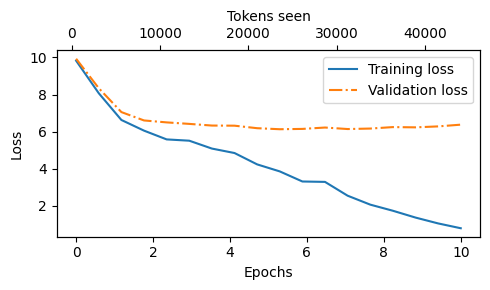

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

The resulting training and validation loss plot is shown in figure 5.12. As we can see, both the training and validation losses start to improve for the first epoch. However, the losses start to diverge past the second epoch. This divergence and the fact that the validation loss is much larger than the training loss indicate that the model is overfitting to the training data. We can confirm that the model memorizes the training data verbatim by searching for the generated text snippets, such as quite insensible to the irony in the “The Verdict” text file.

This memorization is expected since we are working with a very, very small training dataset and training the model for multiple epochs. Usually, it’s common to train a model on a much larger dataset for only one epoch.

### Decoding strategies to control randomness

Let’s look at text generation strategies (also called decoding strategies) to generate more original text. First, we will briefly revisit the generate_text_simple function that we used inside generate_and_print_sample earlier. Then we will cover two techniques, temperature scaling and top-k sampling, to improve this function.

We begin by transferring the model back from the GPU to the CPU since inference with a relatively small model does not require a GPU. Also, after training, we put
the model into evaluation mode to turn off random components such as dropout:

In [28]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query)

In [29]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




As explained earlier, the generated token is selected at each generation step corresponding to the largest probability score among all tokens in the vocabulary. This
means that the LLM will always generate the same outputs even if we run the preceding generate_text_simple function multiple times on the same start context (Every
effort moves you).

#### Temperature scaling

Let’s now look at temperature scaling, a technique that adds a probabilistic selection process to the next-token generation task. Previously, inside the generate_text_simple
function, we always sampled the token with the highest probability as the next token using torch.argmax, also known as greedy decoding. To generate text with more variety,
we can replace argmax with a function that samples from a probability distribution (here, the probability scores the LLM generates for each vocabulary entry at each
token generation step).

In [30]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

Next, assume the LLM is given the start context "every effort moves you" and gener
ates the following next-token logits:

In [31]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

As discussed in chapter 4, inside generate_text_simple, we convert the logits into probabilities via the softmax function and obtain the token ID corresponding to the generated token via the argmax function, which we can then map back into text via the inverse vocabulary:

In [32]:
probs = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probs).item()
print(inverse_vocab[next_token_id])

forward


Since the largest logit value and, correspondingly, the largest softmax probability score are in the fourth position (index position 3 since Python uses 0 indexing), the
generated word is "forward".

To implement a probabilistic sampling process, we can now replace argmax with the multinomial function in PyTorch:

In [33]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probs, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


The printed output is "forward" just like before. What happened? The multinomial function samples the next token proportional to its probability score. In other words, "forward" is still the most likely token and will be selected by multinomial most of the time but not all the time. To illustrate this, let’s implement a function that repeats this sampling 1,000 times:

In [34]:
def print_sampled_tokens(probs):
    torch.manual_seed(123)
    sample = [torch.multinomial(probs, num_samples=1).item()
     for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} -> {inverse_vocab[i]}")

print("The sampling output:")
print_sampled_tokens(probs)

The sampling output:
73 -> closer
0 -> every
0 -> effort
582 -> forward
2 -> inches
0 -> moves
0 -> pizza
343 -> toward


As we can see, the word forward is sampled most of the time (582 out of 1,000 times), but other tokens such as closer, inches, and toward will also be sampled some of
the time. This means that if we replaced the argmax function with the multinomial function inside the generate_and_print_sample function, the LLM would some times generate texts such as every effort moves you toward, every effort moves you inches, and every effort moves you closer instead of every effort moves you forward.

We can further control the distribution and selection process via a concept called temperature scaling. Temperature scaling is just a fancy description for dividing the logits by a number greater than 0:

In [35]:
from src.Utilities.SamplingUtilities import softmax_with_temperature

Temperatures greater than 1 result in more uniformly distributed token probabilities, and temperatures smaller than 1 will result in more confident (sharper or more peaky)
distributions. Let’s illustrate this by plotting the original probabilities alongside probabilities scaled with different temperature values:

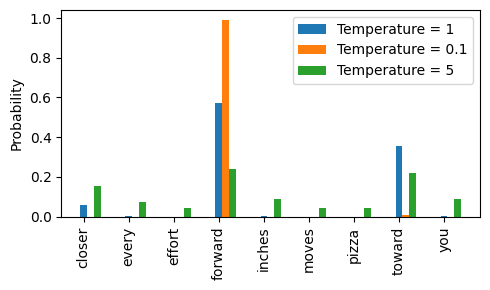

In [36]:
temperatures = [1, 0.1, 5]
scaled_probs = [softmax_with_temperature(next_token_logits, T)
        for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probs[i],
           bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

A temperature of 1 divides the logits by 1 before passing them to the softmax function to compute the probability scores. In other words, using a temperature of 1 is the same as not using any temperature scaling. In this case, the tokens are selected with a probability equal to the original softmax probability scores via the multinomial sam
pling function in PyTorch. For example, for the temperature setting 1, the token corresponding to “forward” would be selected about 60% of the time.

Also, as we can see, applying very small temperatures, such as 0.1, will result in sharper distributions such that the behavior of the multinomial function selects the most likely token (here, "forward") almost 100% of the time, approaching the behavior of the argmax function. Likewise, a temperature of 5 results in a more uniform distribution where other tokens are selected more often. This can add more variety to the generated texts but also more often results in nonsensical text. For
example, using the temperature of 5 results in texts such as every effort moves you pizza about 4% of the time.

#### Top-k sampling

We’ve now implemented a probabilistic sampling approach coupled with temperature scaling to increase the diversity of the outputs. We saw that higher temperature values result in more uniformly distributed next-token probabilities, which result in more diverse outputs as it reduces the likelihood of the model repeatedly selecting the most probable token. This method allows for the exploring of less likely but potentially more interesting and creative paths in the generation process. However, one downside of this approach is that it sometimes leads to grammatically incorrect or completely nonsensical outputs such as every effort moves you pizza.

"Top-k sampling", when combined with probabilistic sampling and temperature scaling, can improve the text generation results. In top-k sampling, we can restrict the
sampled tokens to the top-k most likely tokens and exclude all other tokens from the selection process by masking their probability scores.

The top-k approach replaces all nonselected logits with negative infinity value (-inf), such that when computing the softmax values, the probability scores of the non-top-k
tokens are 0, and the remaining probabilities sum up to 1. (You may remember this masking trick from the causal attention module)

In code, we can implement the top-k procedure as follows, starting with the selection of the tokens with the largest logit values:

In [37]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


Subsequently, we apply PyTorch’s where function to set the logit values of tokens that are
below the lowest logit value within our top-three selection to negative infinity (-inf):

In [38]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


Lastly, let’s apply the softmax function to turn these into next-token probabilities:

In [39]:
topk_probs = torch.softmax(new_logits, dim=0)
print(topk_probs)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


As we can see, the result of this top-three approach are three non-zero probability scores.

We can now apply the temperature scaling and multinomial function for probabilistic sampling to select the next token among these three non-zero probability scores to generate the next token. We do this next by modifying the text generation function.

#### Modifying the text generation function

Now, let’s combine temperature sampling and top-k sampling to modify the generate_text_simple function we used to generate text via the LLM earlier, creating a new generate function.

In [40]:
from src.Utilities.GenerationUtilities import generate

torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=40,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=10,
    temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"
His up. She couldn't to face that my by his last word. But I yourself comfortable--and here are the cry out, it. Stroud. Gisburn had put it


As we can see, the generated text is very different from the one we previously generated via the generate_simple function, which was a memorized passage from the training set.

### Loading and saving model weights in PyTorch

Thus far, we have discussed how to numerically evaluate the training progress and pretrain an LLM from scratch. Even though both the LLM and dataset were relatively
small, this exercise showed that pretraining LLMs is computationally expensive. Thus, it is important to be able to save the LLM so that we don’t have to rerun the training
every time we want to use it in a new session.

Fortunately, saving a PyTorch model is relatively straightforward. The recommended way is to save a model’s state_dict, a dictionary mapping each layer to its parameters,
using the torch.save function:

In [41]:
torch.save(model.state_dict(), "ModelWeights/model.pth")

"model.pth" is the filename where the state_dict is saved. The .pth extension is a convention for PyTorch files, though we could technically use any file extension.

Then, after saving the model weights via the state_dict, we can load the model weights into a new GPTModel model instance:

In [42]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("ModelWeights/model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query)

As discussed in chapter 4, dropout helps prevent the model from overfitting to the training data by randomly “dropping out” of a layer’s neurons during training. However, during inference, we don’t want to randomly drop out any of the information the network has learned. Using model.eval() switches the model to evaluation mode for inference, disabling the dropout layers of the model. **_If we plan to continue pretraining a model later—for example, using the train_model_simple function we defined earlier in this chapter—saving the optimizer state is also recommended._**

**_Adaptive optimizers such as AdamW store additional parameters for each model weight. AdamW uses historical data to adjust learning rates for each model parameter
dynamically. Without it, the optimizer resets, and the model may learn suboptimally or even fail to converge properly, which means it will lose the ability to generate coherent text._** Using torch.save, we can save both the model and optimizer state_dict contents:

In [43]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "ModelWeights/model_and_optimizer.pth"
)

Then we can restore the model and optimizer states by first loading the saved data via torch.load and then using the load_state_dict method:

In [44]:
checkpoint = torch.load("ModelWeights/model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

### Loading pretrained weights from OpenAI

Previously, we trained a small GPT-2 model using a limited dataset comprising a short story book. This approach allowed us to focus on the fundamentals without the need
for extensive time and computational resources.

 Fortunately, OpenAI openly shared the weights of their GPT-2 models, thus eliminating the need to invest tens to hundreds of thousands of dollars in retraining the
model on a large corpus ourselves. So, let’s load these weights into our GPTModel class and use the model for text generation. Here, weights refer to the weight parameters
stored in the .weight attributes of PyTorch’s Linear and Embedding layers, for example. We accessed them earlier via model.parameters() when training the model. In
chapter 6, will reuse these pretrained weights to fine-tune the model for a text classification task and follow instructions similar to ChatGPT.

Note that OpenAI originally saved the GPT-2 weights via TensorFlow, which we have to install to load the weights in Python.

The download code is relatively long, mostly boilerplate, and not very interesting.

Hence, instead of devoting precious space to discussing Python code for fetching files from the internet, we download the gpt_download.py Python module directly from this chapter’s online repository:

In [45]:
"""
# Uncomment the following lines to download the gpt_download.py module if needed.
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, "Utilities/gpt_2_weight_download.py")
"""

'\n# Uncomment the following lines to download the gpt_download.py module if needed.\nimport urllib.request\nurl = (\n    "https://raw.githubusercontent.com/rasbt/"\n    "LLMs-from-scratch/main/ch05/"\n    "01_main-chapter-code/gpt_download.py"\n)\nfilename = url.split(\'/\')[-1]\nurllib.request.urlretrieve(url, "Utilities/gpt_2_weight_download.py")\n'

Next, after downloading this file to the local directory of your Python session, you should briefly inspect the contents of this file to ensure that it was saved correctly and contains valid Python code.

We can now import the download_and_load_gpt2 function from the gpt_download.py file as follows, which will load the GPT-2 architecture settings (settings) and weight parameters (params) into our Python session:

In [46]:
from src.Utilities.gpt_2_weight_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 41.8kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.79MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 52.0kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [10:01<00:00, 827kiB/s]  
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 2.00MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.78MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.90MiB/s]


NOTE If the download code does not work for you, it could be due to intermittent internet connection, server problems, or changes in how OpenAI
shares the weights of the open-source GPT-2 model. In this case, please visit this chapter’s online code repository at https://github.com/rasbt/LLMs
from-scratch for alternative and updated instructions, and reach out via the Manning Forum for further questions.

In [47]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


Both settings and params are Python dictionaries. The settings dictionary stores the LLM architecture settings similarly to our manually defined GPT_CONFIG_124M settings.
The params dictionary contains the actual weight tensors. Note that we only printed the dictionary keys because printing the weight contents would take up too much
screen space; however, we can inspect these weight tensors by printing the whole dictionary via print(params) or by selecting individual tensors via the respective dictionary keys, for example, the embedding layer weights:

In [48]:
print("The weights of the token embedding layer are: ")
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

The weights of the token embedding layer are: 
[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


We downloaded and loaded the weights of the smallest GPT-2 model via the download_and_load_gpt2(model_size="124M", ...) setting. OpenAI also shares the weights of
larger models: 355M, 774M, and 1558M. The overall architecture of these differently sized GPT models is the same, except that different architectural elements are repeated different numbers of times and the embedding size differs. The remaining code in this chapter is also compatible with these larger models.

 After loading the GPT-2 model weights into Python, we still need to transfer them from the settings and params dictionaries into our GPTModel instance. First, we create a dictionary that lists the differences between the different GPT model sizes:

In [65]:
model_configs = {
    "gpt2-small (124M)": {"embedding_dim": 768, "num_layers": 12, "num_heads": 12},
    "gpt2-medium (355M)": {"embedding_dim": 1024, "num_layers": 24, "num_heads": 16},
    "gpt2-large (774M)": {"embedding_dim": 1280, "num_layers": 36, "num_heads": 20},
    "gpt2-xl (1558M)": {"embedding_dim": 1600, "num_layers": 48, "num_heads": 25},
}

Suppose we are interested in loading the smallest model, "gpt2-small (124M)". We can use the corresponding settings from the model_configs table to update our full-length
GPT_CONFIG_124M we defined and used earlier:

In [66]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

You may remember that we used a 256-token length earlier, but the original GPT-2 models from OpenAI were trained with a 1,024-token length, so we have to update the NEW_CONFIG accordingly:

In [67]:
NEW_CONFIG.update({"context_length": 1024})

Also, OpenAI used bias vectors in the multi-head attention module’s linear layers to implement the query, key, and value matrix computations. _**Bias vectors are not commonly used in LLMs anymore as they don’t improve the modeling performance and are thus unnecessary._** However, since we are working with pretrained weights, we need to match the settings for consistency and enable these bias vectors:

In [68]:
NEW_CONFIG.update({"qkv_bias": True})

We can now use the updated NEW_CONFIG dictionary to initialize a new GPTModel instance:

In [69]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): 

By default, the GPTModel instance is initialized with random weights for pretraining.

The last step to using OpenAI’s model weights is to override these random weights with the weights we loaded into the params dictionary... We define a load_weights_into_gpt function that loads the weights from the params dictionary into a GPTModel instance gpt.

In [70]:
from src.Utilities.GPTWeightLoader import load_weights_into_gpt

In the load_weights_into_gpt function, we carefully match the weights from
OpenAI’s implementation with our GPTModel implementation. To pick a specific
example, OpenAI stored the weight tensor for the output projection layer for the
first transformer block as params["blocks"][0]["attn"]["c_proj"]["w"]. In our
implementation, this weight tensor corresponds to gpt.trf_blocks[b].att.out_proj
.weight, where gpt is a GPTModel instance.
 Developing the load_weights_into_gpt function took a lot of guesswork since
OpenAI used a slightly different naming convention from ours. However, the assign
function would alert us if we try to match two tensors with different dimensions. Also,
if we made a mistake in this function, we would notice this, as the resulting GPT
model would be unable to produce coherent text.
 Let’s now try the load_weights_into_gpt out in practice and load the OpenAI
model weights into our GPTModel instance gpt:

In [71]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): 

If the model is loaded correctly, we can now use it to generate new text using our previous generate function:

In [72]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something interrupts your control flow. As you may observe I


We can be confident that we loaded the model weights correctly because the model can produce coherent text. A tiny mistake in this process would cause the model to fail. In
the following chapters, we will work further with this pretrained model and fine-tune it to classify text and follow instructions.

### Summary:
- When LLMs generate text, they output one token at a time.
- By default, the next token is generated by converting the model outputs into probability scores and selecting the token from the vocabulary that corresponds to the highest probability score, which is known as “greedy decoding.”
- Using probabilistic sampling and temperature scaling, we can influence the diversity and coherence of the generated text.
- Training and validation set losses can be used to gauge the quality of text generated by LLM during training.
- Pretraining an LLM involves changing its weights to minimize the training loss.
- The training loop for LLMs itself is a standard procedure in deep learning, using a conventional cross entropy loss and AdamW optimizer.
- Pretraining an LLM on a large text corpus is time- and resource-intensive, so we can load openly available weights as an alternative to pretraining the model on a large dataset ourselves.